<h1 align="center">4. Simulação - Resiliência</h1>

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / 'src'))
from notebook_setup import *

# Carregar artefatos do notebook 02 e 03
G_principal, stops_com_modal = carregar_artefatos()
df_centralidades = pd.read_parquet(DATA_PROCESSED / 'centralidades.parquet')

print(f"✓ G_principal:      {G_principal.number_of_nodes():,} nós, {G_principal.number_of_edges():,} arestas")
print(f"✓ df_centralidades: {len(df_centralidades):,} linhas")

✓ G_principal:      22,099 nós, 32,163 arestas
✓ df_centralidades: 22,099 linhas


In [2]:
# Ranking composto: média das 3 centralidades normalizadas

# Cada centralidade é normalizada para [0, 1] dividindo pelo máximo, e o composite_score é a média aritmética das 3 normalizadas.

for col in ['degree_centrality', 'betweenness_centrality', 'closeness_centrality']:
    df_centralidades[f'{col}_norm'] = (
        df_centralidades[col] / df_centralidades[col].max()
    )

df_centralidades['composite_score'] = (
    df_centralidades['degree_centrality_norm']
    + df_centralidades['betweenness_centrality_norm']
    + df_centralidades['closeness_centrality_norm']
) / 3

print("Top 10 paradas pelo ranking composto:")
print(
    df_centralidades.nlargest(10, 'composite_score')
    [['stop_name', 'modal_label', 'degree', 'betweenness_centrality',
      'closeness_centrality', 'composite_score']]
    .to_string(index=False)
)

Top 10 paradas pelo ranking composto:
              stop_name modal_label  degree  betweenness_centrality  closeness_centrality  composite_score
   Corinthians-itaquera        CPTM      61                0.203033              0.049659         0.814091
         Lapa (linha 8)        CPTM      59                0.142682              0.047906         0.739541
                    Luz        CPTM      16                0.364513              0.052821         0.737511
                Tatuapé        CPTM      32                0.258032              0.051430         0.720040
                Santana       Metrô      63                0.114060              0.043573         0.708268
                   Brás        CPTM       7                0.380227              0.052360         0.700762
                Tatuapé        CPTM      32                0.192695              0.051081         0.660563
Palmeiras - Barra Funda        CPTM      40                0.127750              0.049714         0.637327

In [3]:
# Gerar Sequência de frações de nós a remover
# Refinado no início (0,1%) e mais espaçado depois (0,5%)


# 0% a 5%, passo 0,1%
fracoes_inicio = np.arange(0.000, 0.050 + 0.001, 0.001)
# 5% a 20%, passo 0,5%
fracoes_fim = np.arange(0.055, 0.200 + 0.005, 0.005)
# Concatenar
fracoes = np.unique(np.concatenate([fracoes_inicio, fracoes_fim]))

# Converter para número absoluto de nós
n_total = G_principal.number_of_nodes()
n_remover = (fracoes * n_total).astype(int)

print(f"Total de pontos de remoção: {len(fracoes)}")
print(f"Frações: de {fracoes.min():.3f} até {fracoes.max():.3f}")
print(f"Nós removidos: de {n_remover.min()} até {n_remover.max():,}")

Total de pontos de remoção: 82
Frações: de 0.000 até 0.205
Nós removidos: de 0 até 4,530


In [4]:
# Funções auxiliares de métricas de impacto (LCC e κ de Molloy-Reed)

def lcc_size(G):
    """Tamanho do maior componente conexo."""
    if G.number_of_nodes() == 0:
        return 0
    return len(max(nx.connected_components(G), key=len))


def molloy_reed_kappa(G):
    """Parâmetro κ = <k²>/<k> de Molloy-Reed.
    
    Por convenção: κ > 2 indica existência de componente gigante;
    κ < 2 sugere fragmentação.
    """
    if G.number_of_nodes() == 0:
        return 0.0
    graus = np.array([d for _, d in G.degree()])
    if graus.mean() == 0:
        return 0.0
    return (graus ** 2).mean() / graus.mean()


# Validação no grafo original
print(f"LCC inicial:    {lcc_size(G_principal):,} nós ({lcc_size(G_principal)/n_total*100:.2f}%)")
print(f"κ inicial:      {molloy_reed_kappa(G_principal):.3f}")

LCC inicial:    22,099 nós (100.00%)
κ inicial:      4.773


In [5]:
# Simulação de ataque (direcionado ou aleatório)


def simular_remocao(G_inicial, nos_em_ordem, n_remover_seq):
    """Remove nós sequencialmente e mede LCC e κ a cada ponto.
    
    Parâmetros
    ----------
    G_inicial : nx.Graph
        Grafo original (não é modificado)
    nos_em_ordem : list
        Sequência de nós a remover (ordem importa)
    n_remover_seq : list of int
        Quantidades cumulativas de nós a remover em cada ponto da curva
    
    Retorna
    -------
    pd.DataFrame com colunas: n_removidos, lcc, lcc_pct, kappa
    """
    G = G_inicial.copy()
    resultados = []
    
    # Ponto 0 (nada removido)
    resultados.append({
        'n_removidos': 0,
        'lcc': lcc_size(G),
        'lcc_pct': lcc_size(G) / G_inicial.number_of_nodes() * 100,
        'kappa': molloy_reed_kappa(G),
    })
    
    n_removidos_atual = 0
    for n_alvo in n_remover_seq:
        if n_alvo == 0:
            continue
        # Remover nós até atingir n_alvo
        while n_removidos_atual < n_alvo and n_removidos_atual < len(nos_em_ordem):
            G.remove_node(nos_em_ordem[n_removidos_atual])
            n_removidos_atual += 1
        resultados.append({
            'n_removidos': n_removidos_atual,
            'lcc': lcc_size(G),
            'lcc_pct': lcc_size(G) / G_inicial.number_of_nodes() * 100,
            'kappa': molloy_reed_kappa(G),
        })
    
    return pd.DataFrame(resultados)


print("✓ Função simular_remocao definida")

✓ Função simular_remocao definida


In [6]:
# Rodar 4 Ataques direcionados: degree, betweenness, closeness, composite

import time

ataques = {
    'degree':      'degree_centrality',
    'betweenness': 'betweenness_centrality',
    'closeness':   'closeness_centrality',
    'composite':   'composite_score',
}

resultados_ataques = {}

for nome, coluna in ataques.items():
    print(f"\nRodando ataque por {nome}...")
    t0 = time.time()
    
    # Ordenar nós por valor decrescente da métrica
    ordem = df_centralidades.sort_values(coluna, ascending=False)['stop_id'].tolist()
    
    # Simular
    df_curva = simular_remocao(G_principal, ordem, n_remover.tolist())
    df_curva['cenario'] = f'ataque_{nome}'
    df_curva['frac_removida'] = df_curva['n_removidos'] / n_total
    
    resultados_ataques[nome] = df_curva
    print(f"  ✓ Concluído em {time.time()-t0:.1f}s")

print("\n✓ Todos os ataques direcionados completos")


Rodando ataque por degree...
  ✓ Concluído em 1.7s

Rodando ataque por betweenness...
  ✓ Concluído em 2.0s

Rodando ataque por closeness...
  ✓ Concluído em 2.0s

Rodando ataque por composite...
  ✓ Concluído em 1.4s

✓ Todos os ataques direcionados completos


In [7]:
# Falha aleatória: 30 repetições com seeds diferentes


resultados_aleatorios = []
n_repeticoes = 30

t0 = time.time()
for seed in range(n_repeticoes):
    rng = np.random.RandomState(seed)
    ordem_aleatoria = rng.permutation(list(G_principal.nodes())).tolist()
    
    df_curva = simular_remocao(G_principal, ordem_aleatoria, n_remover.tolist())
    df_curva['cenario'] = 'aleatorio'
    df_curva['seed'] = seed
    df_curva['frac_removida'] = df_curva['n_removidos'] / n_total
    
    resultados_aleatorios.append(df_curva)
    
    if (seed + 1) % 5 == 0:
        print(f"  Concluídas {seed+1}/{n_repeticoes} repetições ({time.time()-t0:.1f}s)")

df_aleatorio = pd.concat(resultados_aleatorios, ignore_index=True)

# Estatísticas agregadas (média e desvio entre as repetições)
df_aleatorio_agg = (
    df_aleatorio
    .groupby('n_removidos')
    .agg(
        lcc_pct_mean=('lcc_pct', 'mean'),
        lcc_pct_std=('lcc_pct', 'std'),
        kappa_mean=('kappa', 'mean'),
        kappa_std=('kappa', 'std'),
    )
    .reset_index()
)
df_aleatorio_agg['frac_removida'] = df_aleatorio_agg['n_removidos'] / n_total

print(f"\n✓ {n_repeticoes} repetições aleatórias completas em {time.time()-t0:.1f}s")

  Concluídas 5/30 repetições (7.9s)
  Concluídas 10/30 repetições (15.6s)
  Concluídas 15/30 repetições (22.5s)
  Concluídas 20/30 repetições (29.4s)
  Concluídas 25/30 repetições (36.2s)
  Concluídas 30/30 repetições (43.2s)

✓ 30 repetições aleatórias completas em 43.2s


In [8]:
# Consolidar resultados em um DataFrame único


# Ataques (4 cenários, 1 curva cada)
df_ataques_consolidado = pd.concat(resultados_ataques.values(), ignore_index=True)

# Salvar tudo para uso na 4.3
df_ataques_consolidado.to_parquet(DATA_PROCESSED / 'resiliencia_ataques.parquet')
df_aleatorio.to_parquet(DATA_PROCESSED / 'resiliencia_aleatorio_raw.parquet')
df_aleatorio_agg.to_parquet(DATA_PROCESSED / 'resiliencia_aleatorio_agg.parquet')

print("✓ Salvos:")
print(f"  - resiliencia_ataques.parquet ({len(df_ataques_consolidado)} linhas)")
print(f"  - resiliencia_aleatorio_raw.parquet ({len(df_aleatorio)} linhas)")
print(f"  - resiliencia_aleatorio_agg.parquet ({len(df_aleatorio_agg)} linhas)")

✓ Salvos:
  - resiliencia_ataques.parquet (328 linhas)
  - resiliencia_aleatorio_raw.parquet (2460 linhas)
  - resiliencia_aleatorio_agg.parquet (82 linhas)


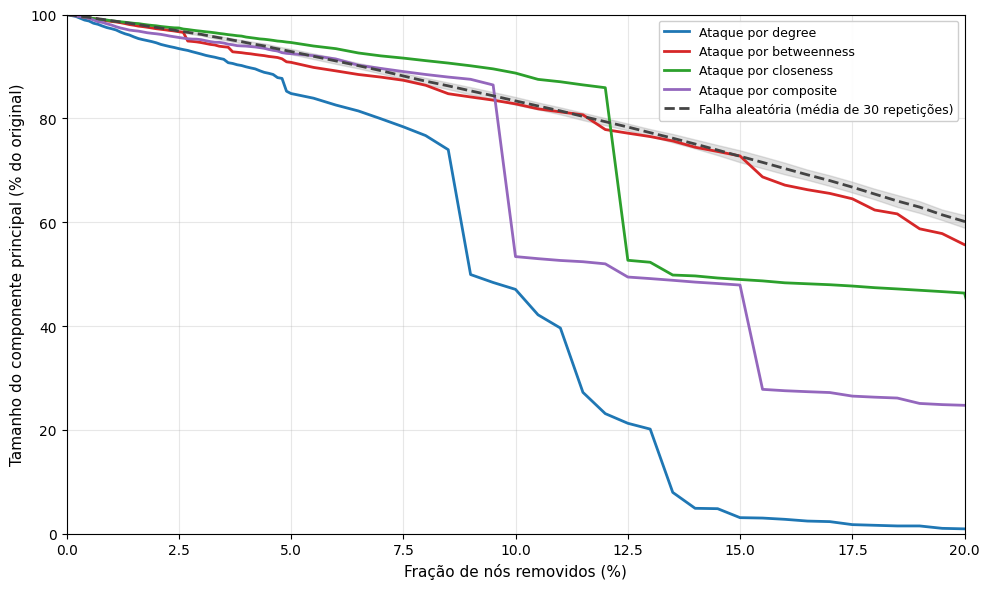

✓ Salvo: outputs/curvas_resiliencia_lcc.png


In [9]:
# Gráfico: evolução do LCC nos 5 cenários

fig, ax = plt.subplots(figsize=(10, 6))

cores_ataques = {
    'degree':      '#1f77b4',
    'betweenness': '#d62728',
    'closeness':   '#2ca02c',
    'composite':   '#9467bd',
}

# Ataques direcionados (linhas sólidas)
for nome, df_curva in resultados_ataques.items():
    ax.plot(
        df_curva['frac_removida'] * 100,
        df_curva['lcc_pct'],
        label=f'Ataque por {nome}',
        color=cores_ataques[nome],
        linewidth=2,
    )

# Falha aleatória (linha cinza com banda de desvio)
ax.fill_between(
    df_aleatorio_agg['frac_removida'] * 100,
    df_aleatorio_agg['lcc_pct_mean'] - df_aleatorio_agg['lcc_pct_std'],
    df_aleatorio_agg['lcc_pct_mean'] + df_aleatorio_agg['lcc_pct_std'],
    color='#888888', alpha=0.25,
)
ax.plot(
    df_aleatorio_agg['frac_removida'] * 100,
    df_aleatorio_agg['lcc_pct_mean'],
    label=f'Falha aleatória (média de {n_repeticoes} repetições)',
    color='#444444', linewidth=2, linestyle='--',
)

ax.set_xlabel('Fração de nós removidos (%)', fontsize=11)
ax.set_ylabel('Tamanho do componente principal (% do original)', fontsize=11)
# ax.set_title('Evolução do componente principal sob diferentes cenários de remoção', fontsize=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 20)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'outputs' / 'curvas_resiliencia_lcc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvo: outputs/curvas_resiliencia_lcc.png")

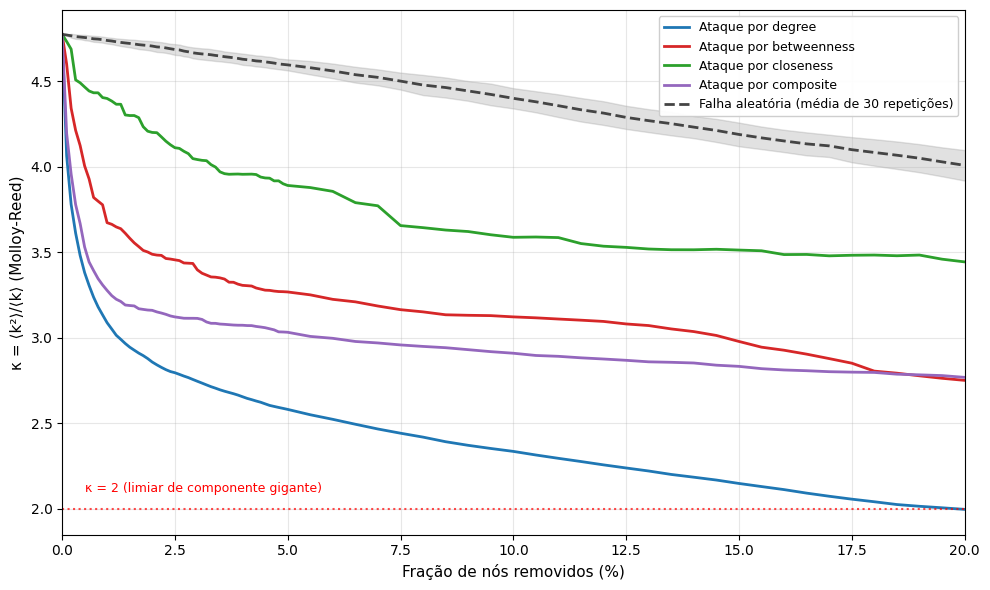

✓ Salvo: outputs/curvas_resiliencia_kappa.png


In [12]:
# Gráfico: evolução do κ Molloy-Reed nos 5 cenários


fig, ax = plt.subplots(figsize=(10, 6))

for nome, df_curva in resultados_ataques.items():
    ax.plot(
        df_curva['frac_removida'] * 100,
        df_curva['kappa'],
        label=f'Ataque por {nome}',
        color=cores_ataques[nome],
        linewidth=2,
    )

ax.fill_between(
    df_aleatorio_agg['frac_removida'] * 100,
    df_aleatorio_agg['kappa_mean'] - df_aleatorio_agg['kappa_std'],
    df_aleatorio_agg['kappa_mean'] + df_aleatorio_agg['kappa_std'],
    color='#888888', alpha=0.25,
)
ax.plot(
    df_aleatorio_agg['frac_removida'] * 100,
    df_aleatorio_agg['kappa_mean'],
    label=f'Falha aleatória (média de {n_repeticoes} repetições)',
    color='#444444', linewidth=2, linestyle='--',
)

# Linha de referência κ = 2 (limiar Molloy-Reed)
ax.axhline(y=2, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(0.5, 2.1, 'κ = 2 (limiar de componente gigante)', fontsize=9, color='red')

ax.set_xlabel('Fração de nós removidos (%)', fontsize=11)
ax.set_ylabel('κ = ⟨k²⟩/⟨k⟩ (Molloy-Reed)', fontsize=11)
# ax.set_title('Evolução do parâmetro κ sob diferentes cenários de remoção', fontsize=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 20)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'outputs' / 'curvas_resiliencia_kappa.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvo: outputs/curvas_resiliencia_kappa.png")

In [11]:
# Tabela síntese: fração crítica para cada cenário

# fc_50: fração que reduz o LCC a 50%
# fc_kappa: fração na qual κ cai abaixo de 2

def fracao_critica(df_curva, alvo_col, alvo_valor, frac_col='frac_removida'):
    """Fração mínima de remoção para atingir alvo_valor na coluna alvo_col."""
    abaixo = df_curva[df_curva[alvo_col] < alvo_valor]
    if len(abaixo) == 0:
        return None
    return abaixo[frac_col].min()


resumo = []
for nome, df_curva in resultados_ataques.items():
    resumo.append({
        'cenario': f'Ataque {nome}',
        'fc_lcc50': fracao_critica(df_curva, 'lcc_pct', 50),
        'fc_kappa2': fracao_critica(df_curva, 'kappa', 2),
    })

resumo.append({
    'cenario': 'Falha aleatória (média)',
    'fc_lcc50': fracao_critica(df_aleatorio_agg, 'lcc_pct_mean', 50),
    'fc_kappa2': fracao_critica(df_aleatorio_agg, 'kappa_mean', 2),
})

df_resumo = pd.DataFrame(resumo)
df_resumo['fc_lcc50'] = (df_resumo['fc_lcc50'] * 100).round(2)
df_resumo['fc_kappa2'] = (df_resumo['fc_kappa2'] * 100).round(2)
df_resumo.columns = ['Cenário', 'Fração crítica LCC<50% (%)', 'Fração crítica κ<2 (%)']

print("\n=== Tabela síntese: frações críticas por cenário ===\n")
print(df_resumo.to_string(index=False))

# Salvar também
df_resumo.to_parquet(DATA_PROCESSED / 'resiliencia_resumo.parquet')


=== Tabela síntese: frações críticas por cenário ===

                Cenário  Fração crítica LCC<50% (%)  Fração crítica κ<2 (%)
          Ataque degree                         9.0                    20.0
     Ataque betweenness                         NaN                     NaN
       Ataque closeness                        13.5                     NaN
       Ataque composite                        12.5                     NaN
Falha aleatória (média)                         NaN                     NaN
